# 5-A2 作業：Talib Strategy Builder

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/5-A2_talib_strategy_builder.ipynb)

**對應影片**：第 5 章 作業 5-A2【Talib Strategies】Talib Strategy Builder

**和影片的差異**

- 新增的起始筆記本：交叉函式與一組 TalibStrategy + TalibFilter 範例已放好。

用 `TalibStrategy` 和 `TalibFilter` 組合各種指標，試試看能不能用在加密貨幣市場！
[TA-Lib 指標清單](https://ta-lib.github.io/ta-lib-python/funcs.html)

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import numpy as np
import talib
import finlab_crypto
from finlab_crypto.talib_filter import TalibFilter
from finlab_crypto.talib_strategy import TalibStrategy

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '4h')

BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


In [4]:
import numbers


def crossover(s1, s2):
    """s1 由下往上穿過 s2（s2 可以是數字或另一條序列）"""
    previous = s2 if isinstance(s2, numbers.Number) else s2.shift()
    return (s1 > s2) & (s1.shift() < previous)


def crossunder(s1, s2):
    """s1 由上往下穿過 s2"""
    previous = s2 if isinstance(s2, numbers.Number) else s2.shift()
    return (s1 < s2) & (s1.shift() > previous)

## 範例：RSI 突破 55 進場、跌破 45 出場，並用 ADX 過濾盤整

TODO：換成你想嘗試的指標與條件。

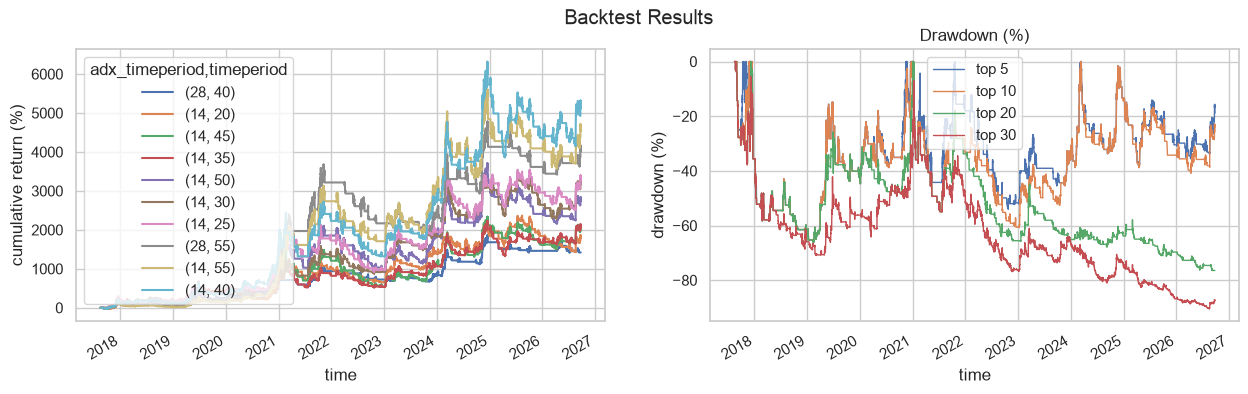

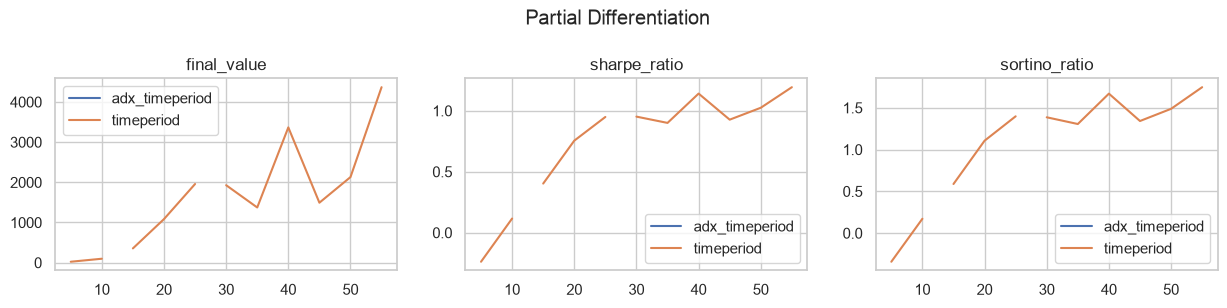

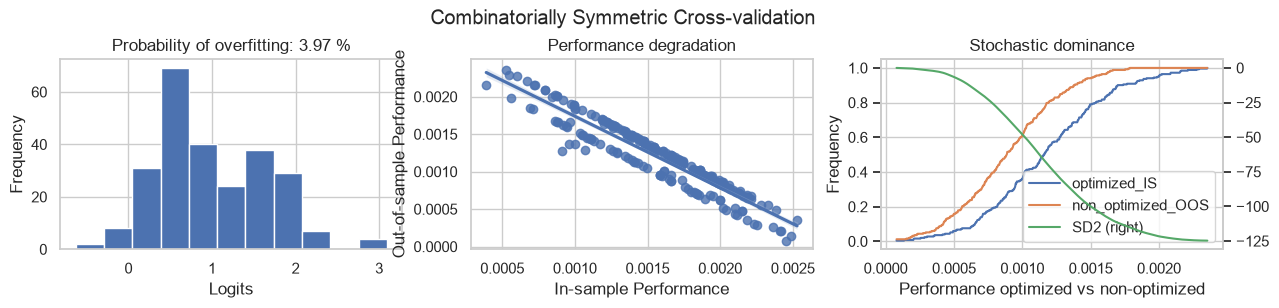

In [5]:
rsi_strategy = TalibStrategy(
    'RSI',
    lambda ohlcv, rsi: crossover(rsi, 55),
    lambda ohlcv, rsi: crossunder(rsi, 45),
)
adx_filter = TalibFilter('ADX', lambda ohlcv, adx: adx > 20)

step = 20 if QUICK_RUN else 5
portfolio = rsi_strategy.backtest(ohlcv, {'timeperiod': np.arange(5, 60, step)},
                                  filters={'adx': adx_filter.create({'timeperiod': [14, 28]})},
                                  freq='4h', plot=True)

## 你的觀察

哪些指標組合的過擬合機率最低？